In [1]:
import pandas as pd

df = pd.read_csv('owid-covid-data.csv')

print(df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

In [2]:
# Raggruppare i dati per continente e calcolare il numero di casi totali
casi_per_continente = df.groupby('continent')['total_cases'].max().reset_index()

# Calcolare la percentuale rispetto al totale mondiale
totale_mondiale = casi_per_continente['total_cases'].sum()
casi_per_continente['percentuale'] = (casi_per_continente['total_cases'] / totale_mondiale) * 100

print(casi_per_continente)

       continent  total_cases  percentuale
0         Africa    4072765.0     1.379413
1           Asia   99373219.0    33.656928
2         Europe   38997490.0    13.208143
3  North America  103436829.0    35.033241
4        Oceania   11861161.0     4.017282
5  South America   37511921.0    12.704993


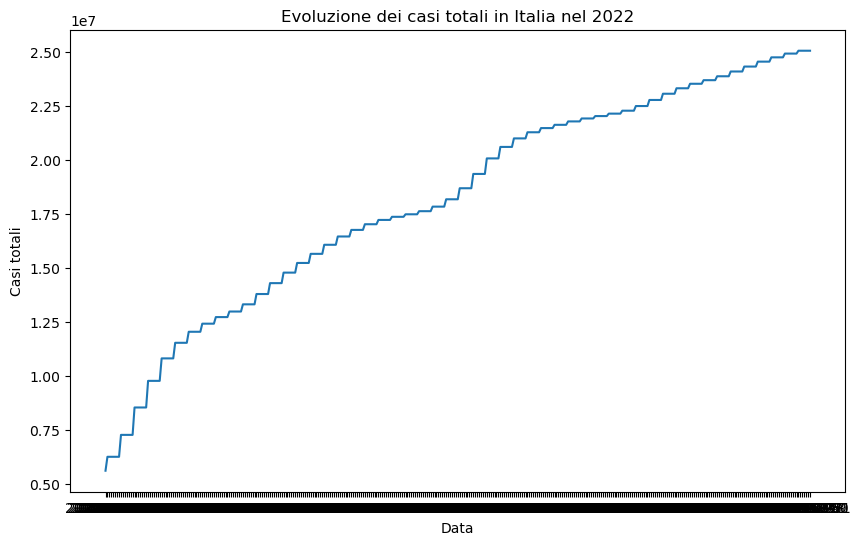

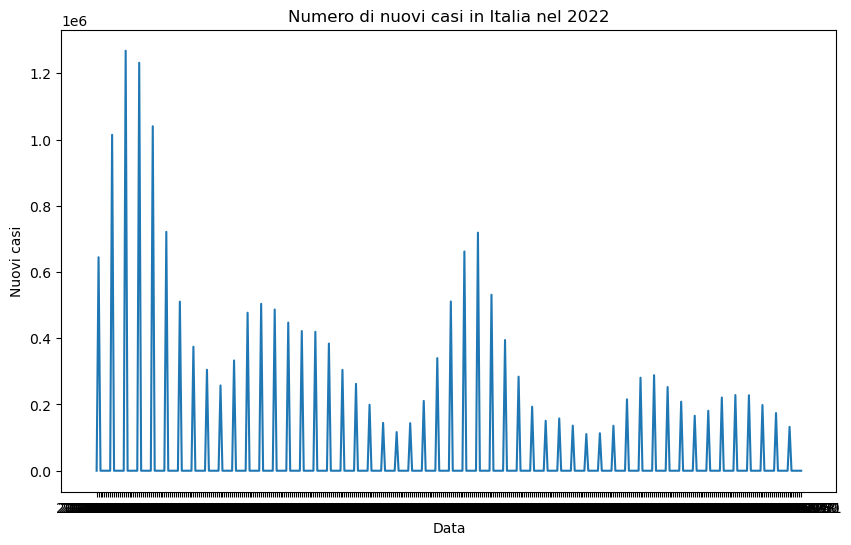

In [3]:
# Selezionare i dati relativi all'Italia nel 2022
italia_2022 = df[(df['location'] == 'Italy') & (df['date'].str.startswith('2022'))]

# Rimuovere i giorni senza misurazioni
italia_2022 = italia_2022.dropna(subset=['new_cases'])

# Mostrare l'evoluzione dei casi totali
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(italia_2022['date'], italia_2022['total_cases'])
plt.xlabel('Data')
plt.ylabel('Casi totali')
plt.title('Evoluzione dei casi totali in Italia nel 2022')
plt.show()

# Mostrare il numero di nuovi casi
plt.figure(figsize=(10,6))
plt.plot(italia_2022['date'], italia_2022['new_cases'])
plt.xlabel('Data')
plt.ylabel('Nuovi casi')
plt.title('Numero di nuovi casi in Italia nel 2022')
plt.show()

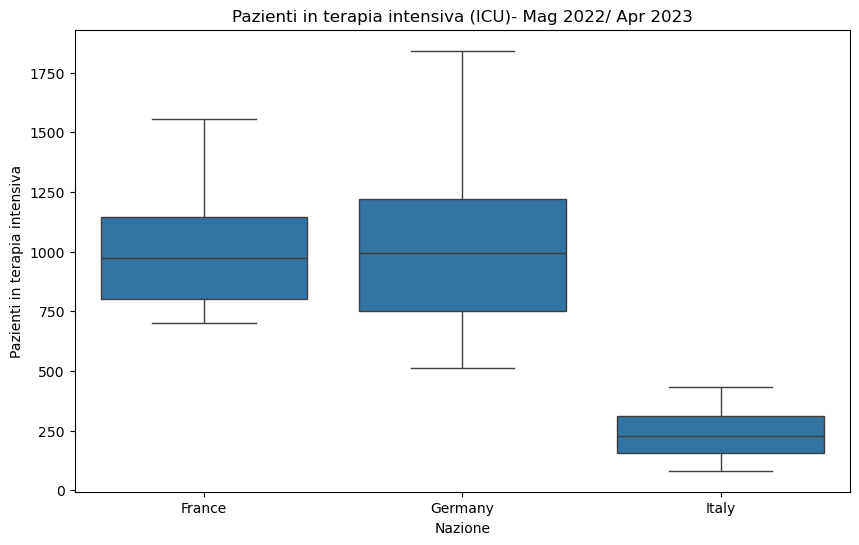

In [5]:
# Selezionare i dati relativi alle nazioni di interesse
nazioni = ['Italy', 'Germany', 'France']
date_range = (df['date'] >= '2022-05-01') & (df['date'] <= '2023-04-30')
df_nazioni = df[(df['location'].isin(nazioni)) & date_range]

# Mostrare la differenza tra le nazioni
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='location', y='icu_patients', data=df_nazioni)
plt.xlabel('Nazione')
plt.ylabel('Pazienti in terapia intensiva')
plt.title('Pazienti in terapia intensiva (ICU)- Mag 2022/ Apr 2023')
plt.show()

#Commento personale: Il grafico mostra che la Germania ha avuto un numero più alto di pazienti in terapia intensiva rispetto all'Italia e alla Francia.

In [9]:
# Selezionare i dati relativi alle nazioni di interesse nel 2021
nazioni = ['Italy', 'Germany', 'France', 'Spain']
date_range = (df['date'] >= '2021-01-01') & (df['date'] <= '2021-12-31')
df_nazioni_2021 = df[(df['location'].isin(nazioni)) & date_range]

# Calcolare la somma dei pazienti ospitalizzati per ogni nazione
pazienti_ospitalizzati = df_nazioni_2021.groupby('location')['hosp_patients'].sum().reset_index()

# Mostrare i risultati
print(pazienti_ospitalizzati)

# Verificare se ci sono dati nulli
dati_nulli = df_nazioni_2021['hosp_patients'].isnull().sum()
print(f"Numero di dati nulli: {dati_nulli}")

# Commento: se ci sono dati nulli, potrebbe essere possibile gestirli tramite sostituzione con la media o la mediana dei valori non nulli,
# ma sarebbe necessario analizzare i dati più a fondo per determinare la strategia migliore.



  location  hosp_patients
0   France      6008717.0
1  Germany            0.0
2    Italy      4419950.0
3    Spain      2411706.0
Numero di dati nulli: 365


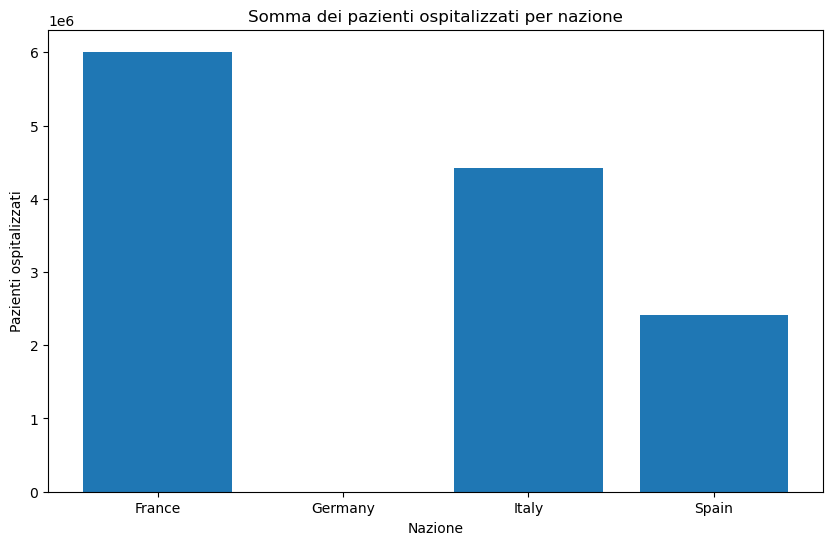

In [10]:
# Nel dubbio facciamo anche un grafico per avere una migliore situazione visiva.

import matplotlib.pyplot as plt

# Mostrare i risultati in un grafico a barre
plt.figure(figsize=(10,6))
plt.bar(pazienti_ospitalizzati['location'], pazienti_ospitalizzati['hosp_patients'])
plt.xlabel('Nazione')
plt.ylabel('Pazienti ospitalizzati')
plt.title('Somma dei pazienti ospitalizzati per nazione')
plt.show()

